<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/Part_3_valentine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm as normSci
import numpy as np
import pandas as pd
from google.colab import files
import io
from pylab import  *


In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_1 = pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df_1.head()

Saving Demand_data.csv to Demand_data.csv


,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
0,1,15,12,13,8,147,46,6
1,2,11,14,9,8,106,49,4
2,3,16,10,12,9,154,48,8
3,4,12,7,8,10,80,48,7
4,5,16,6,14,8,176,44,4


In [3]:
df_1.describe()

,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,14.260274,15.178082,14.210959,8.016438,150.723288,47.805479,8.005479
std,105.510663,3.561190,4.281132,3.587507,0.994354,41.180021,5.093950,3.032783
min,1.000000,5.000000,4.000000,4.000000,5.000000,40.000000,35.000000,0.000000
25%,92.000000,12.000000,12.000000,12.000000,7.000000,122.000000,44.000000,6.000000
50%,183.000000,14.000000,15.000000,14.000000,8.000000,147.000000,48.000000,8.000000
75%,274.000000,17.000000,18.000000,17.000000,9.000000,175.000000,51.000000,10.000000
max,365.000000,25.000000,29.000000,25.000000,12.000000,298.000000,63.000000,17.000000


In [11]:
components = df_1.columns[1:]

mean_demand = df_1[components].mean()
std_demand = df_1[components].std()

summary = pd.DataFrame({
"Mean Demand": mean_demand,
"Std Demand": std_demand
})

summary

,Mean Demand,Std Demand
3235 Movement (units),14.260274,3.561190
Oystersteel Case (units),15.178082,4.281132
Sapphire Crystal (units),14.210959,3.587507
Jubilee Bracelet (units),8.016438,0.994354
Lubricant Oil (grams),150.723288,41.180021
Diamond Marker (units),47.805479,5.093950
Gold Crown (units),8.005479,3.032783


In [12]:
annual_demand = df_1[components].sum()

summary["Annual Demand"] = annual_demand

summary

,Mean Demand,Std Demand,Annual Demand
3235 Movement (units),14.260274,3.561190,5205
Oystersteel Case (units),15.178082,4.281132,5540
Sapphire Crystal (units),14.210959,3.587507,5187
Jubilee Bracelet (units),8.016438,0.994354,2926
Lubricant Oil (grams),150.723288,41.180021,55014
Diamond Marker (units),47.805479,5.093950,17449
Gold Crown (units),8.005479,3.032783,2922


In [13]:
#création du tableau donné dans pdf
inventory_params = pd.DataFrame({
"Component":[
"3235 Movement (units)",
"Oystersteel Case (units)",
"Sapphire Crystal (units)",
"Jubilee Bracelet (units)",
"Lubricant Oil (grams)",
"Diamond Marker (units)",
"Gold Crown (units)"
],

"Lead Time":[60,45,30,35,14,21,40],

"Holding Cost":[1200,400,200,220,50,900,350],

"Ordering Cost":[9000,7000,4000,3500,1000,6000,5000]
})

In [14]:
inventory_data = inventory_params.merge(
summary,
left_on="Component",
right_index=True
)

inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922


In [15]:
#EOQ
inventory_data["EOQ"] = np.sqrt(
(2 * inventory_data["Annual Demand"] * inventory_data["Ordering Cost"])
/ inventory_data["Holding Cost"]
)

In [18]:
#Reoder point R = demand * lead time
inventory_data["Reorder Point"] = (
inventory_data["Mean Demand"] * inventory_data["Lead Time"]
)


In [19]:
#Safety Stock service level 95%
z = 1.65

inventory_data["Safety Stock"] = (
z * inventory_data["Std Demand"] * np.sqrt(inventory_data["Lead Time"])
)

In [20]:
inventory_data

,Component,Lead Time,Holding Cost,Ordering Cost,Mean Demand,Std Demand,Annual Demand,EOQ,Reorder Point,Safety Stock
0,3235 Movement (units),60,1200,9000,14.260274,3.561190,5205,279.419040,855.616438,45.515012
1,Oystersteel Case (units),45,400,7000,15.178082,4.281132,5540,440.340777,683.013699,47.385864
2,Sapphire Crystal (units),30,200,4000,14.210959,3.587507,5187,455.499726,426.328767,32.421819
3,Jubilee Bracelet (units),35,220,3500,8.016438,0.994354,2926,305.122926,280.575342,9.706419
4,Lubricant Oil (grams),14,50,1000,150.723288,41.180021,55014,1483.428461,2110.126027,254.234522
5,Diamond Marker (units),21,900,6000,47.805479,5.093950,17449,482.341511,1003.915068,38.516625
6,Gold Crown (units),40,350,5000,8.005479,3.032783,2922,288.938946,320.219178,31.648655


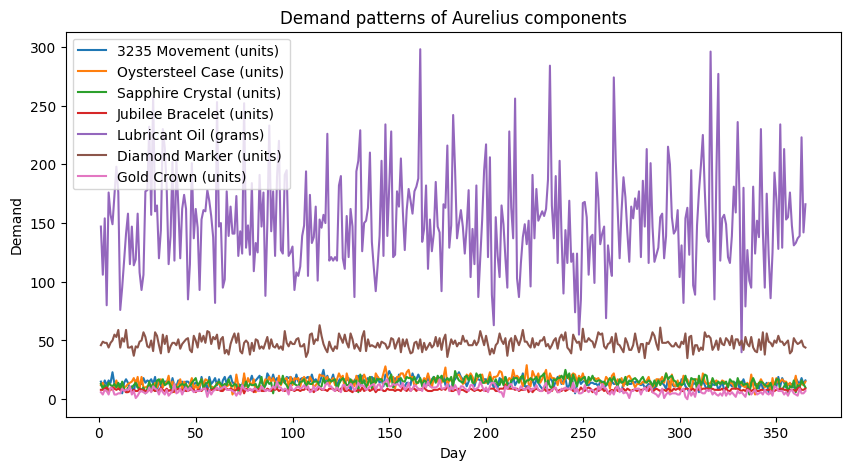

In [21]:
df_1.plot(x="Day", figsize=(10,5))

plt.title("Demand patterns of Aurelius components")
plt.ylabel("Demand")
plt.show()

In [22]:
component = "3235 Movement (units)"

D = inventory_data.loc[inventory_data["Component"] == component, "Annual Demand"].values[0]
S = inventory_data.loc[inventory_data["Component"] == component, "Ordering Cost"].values[0]

In [23]:
holding_values = np.linspace(200,2000,20)

EOQ_values = np.sqrt((2 * D * S) / holding_values)

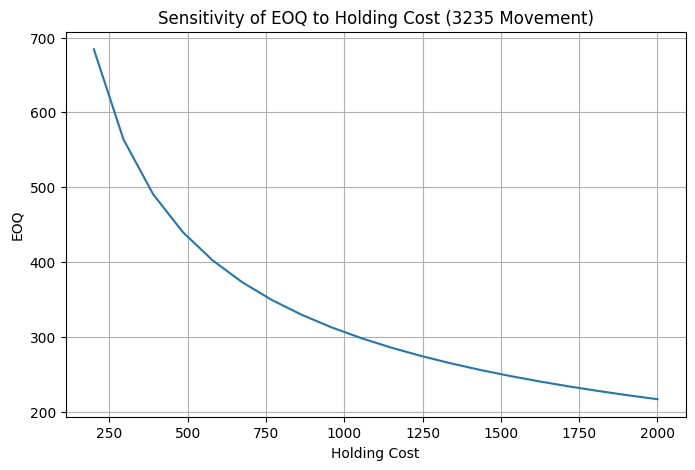

In [24]:
plt.figure(figsize=(8,5))

plt.plot(holding_values, EOQ_values)

plt.xlabel("Holding Cost")
plt.ylabel("EOQ")
plt.title("Sensitivity of EOQ to Holding Cost (3235 Movement)")

plt.grid(True)

plt.show()

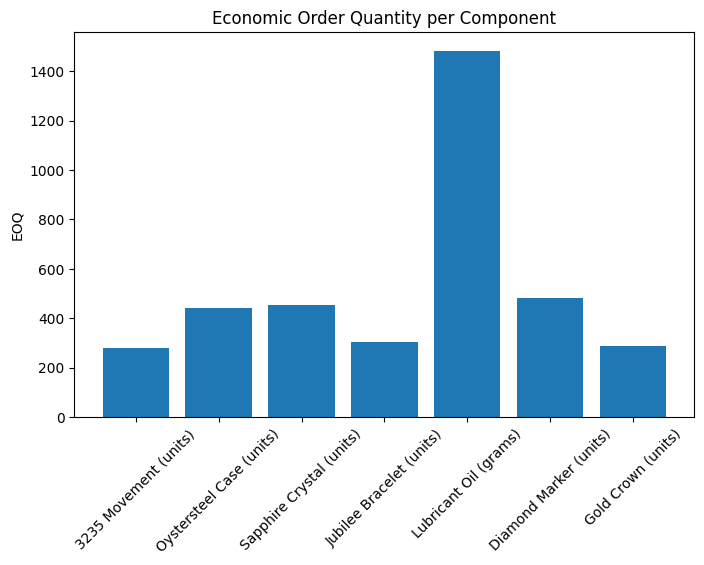

In [25]:
plt.figure(figsize=(8,5))

plt.bar(inventory_data["Component"], inventory_data["EOQ"])

plt.xticks(rotation=45)
plt.ylabel("EOQ")
plt.title("Economic Order Quantity per Component")

plt.show()